# How to use Control toolbox in Python

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter
import control as ct
import control.matlab as cmat 

In [4]:
# define P as a transfer function
P = ct.tf([0, 4],[1,2,3])
cm.show_tf_latex(P)

<IPython.core.display.Math object>

In [5]:
# Second approach
s = ct.tf('s')
P = 4/(s**2 + 2*s + 3)
cm.show_tf_latex(P)

<IPython.core.display.Math object>

In [6]:
# third approach
A = [[0, 1],[-3, -2]]
B = [[0],[1]]
C = [[4, 0],[0, 1]]
D = [[0],[0]]
Pss = ct.ss(A,B,C,D)
cm.show_tf_latex(P)

<IPython.core.display.Math object>

In [7]:
P = ct.ss2tf(A,B,C[0][:],D[0][:]) # to be consistent with the above
# fix some poor scaling
P = cm.near_zero(P)
cm.show_tf_latex(P)

<IPython.core.display.Math object>

# Try some plotting

In [8]:
t = np.arange(0,10,0.01)
y,t = cmat.impulse(Pss,t)

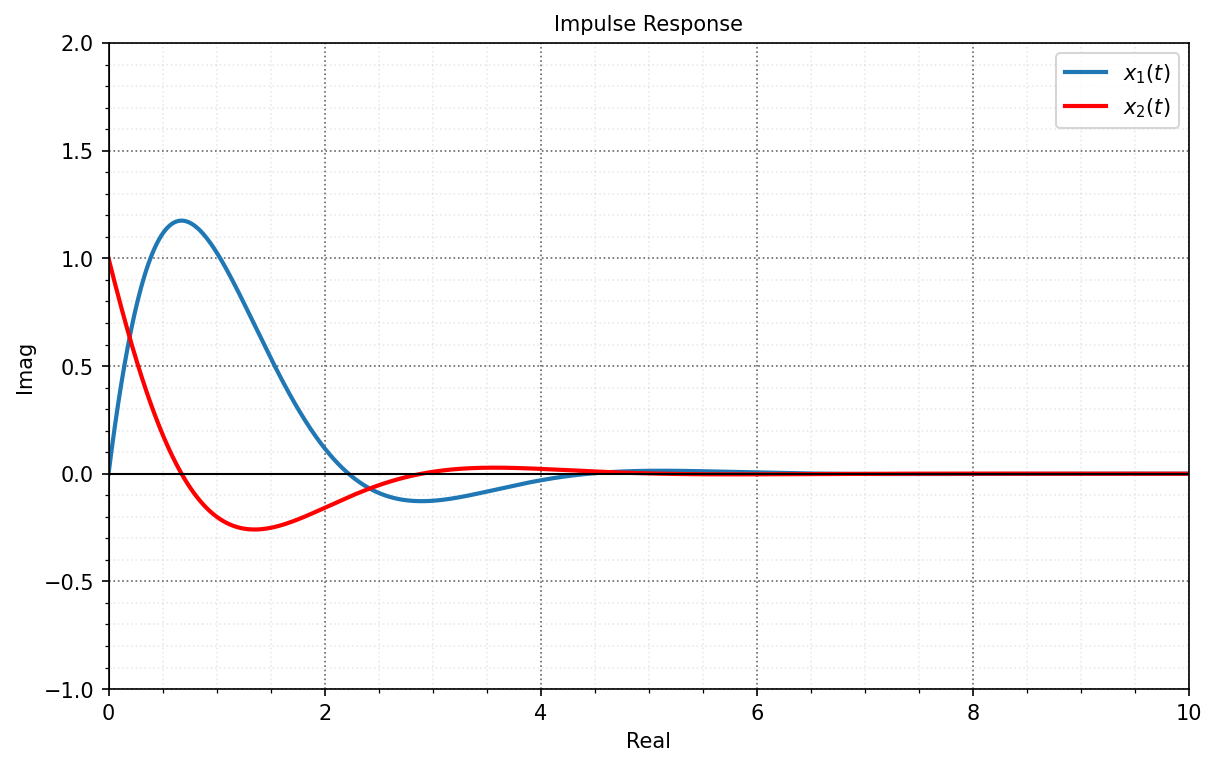

In [9]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax.plot(t,y[:,0],label='$x_1(t)$')
ax.plot(t,y[:,1],'r',label='$x_2(t)$')
ax.minorticks_on()
ax.set_xlim(0,10)
ax.set_ylim(-1,2)
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
ax.set_title('Impulse Response')
bm.nicegrid(ax)
ax.legend()
plt.show()

In [10]:
t = np.arange(0,10,0.001)
y,t = cmat.step(Pss,t)

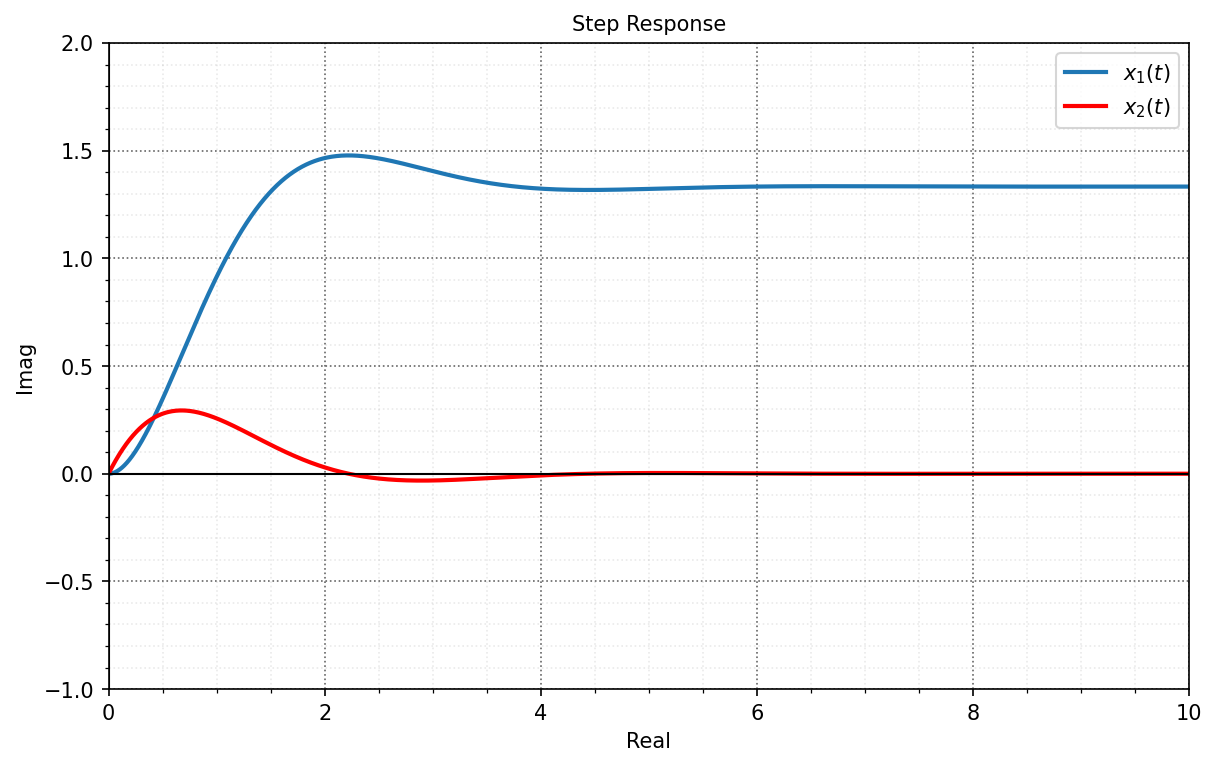

In [11]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax.plot(t,y[:,0],label='$x_1(t)$')
ax.plot(t,y[:,1],'r',label='$x_2(t)$')

bm.nicegrid(ax)
ax.legend()
ax.set_xlim(0,10)
ax.set_ylim(-1,2)
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
ax.set_title('Step Response')
plt.show()


In [12]:
X0 = [0, -1]
y,t = cmat.initial(Pss,t,X0)

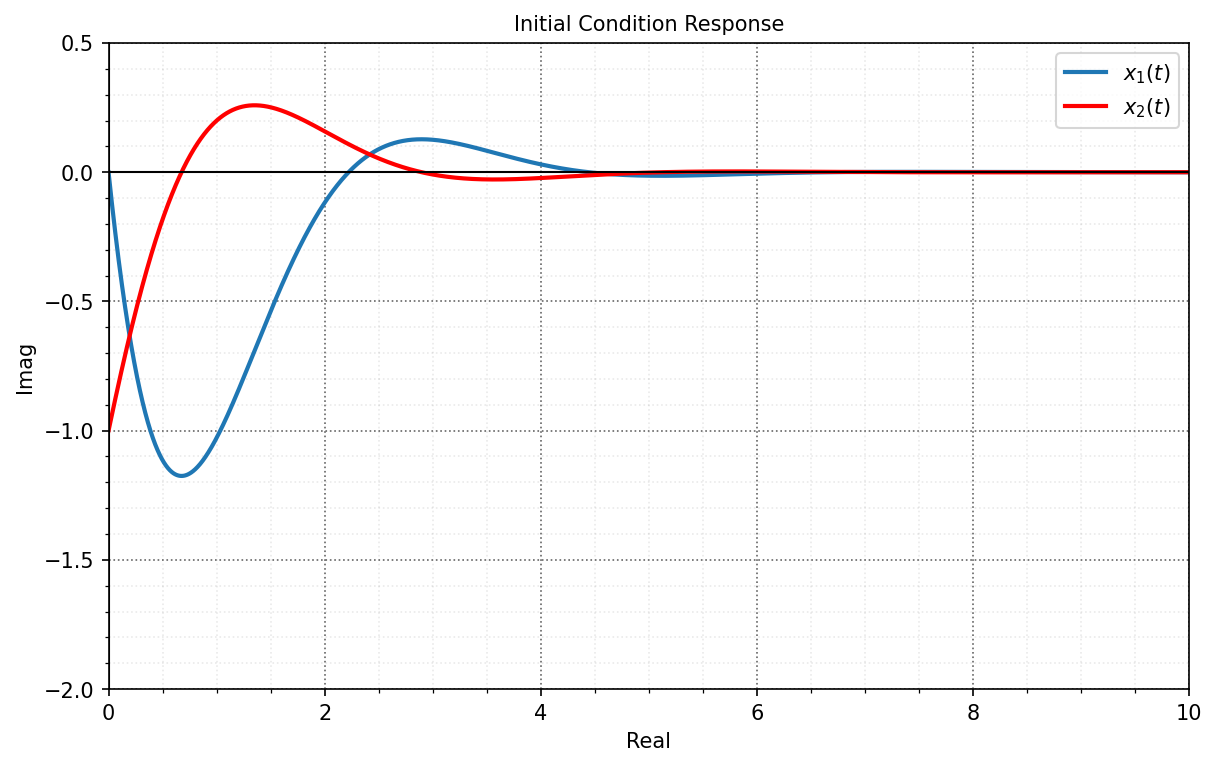

In [13]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax.plot(t,y[:,0],label='$x_1(t)$')
ax.plot(t,y[:,1],'r',label='$x_2(t)$')

bm.nicegrid(ax)
ax.legend()
ax.set_xlim(0,10)
ax.set_ylim(-2,0.5)
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
ax.set_title('Initial Condition Response')
plt.show()

In [14]:
U = np.sin(5*2*np.pi*t)
y,t,xout = cmat.lsim(Pss,U,t,X0)

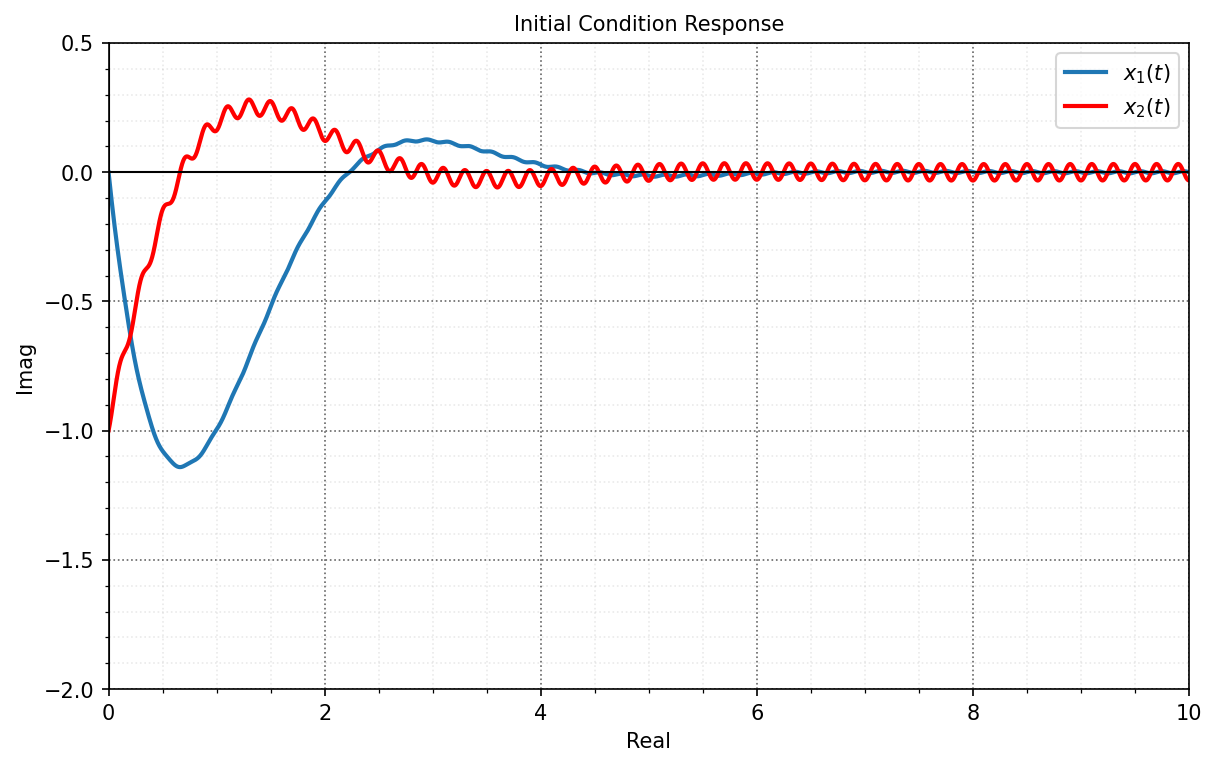

In [15]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax.plot(t,y[:,0],label='$x_1(t)$')
ax.plot(t,y[:,1],'r',label='$x_2(t)$')

bm.nicegrid(ax)
ax.legend()
ax.set_xlim(0,10)
ax.set_ylim(-2,0.5)
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
ax.set_title('Initial Condition Response')
plt.show()


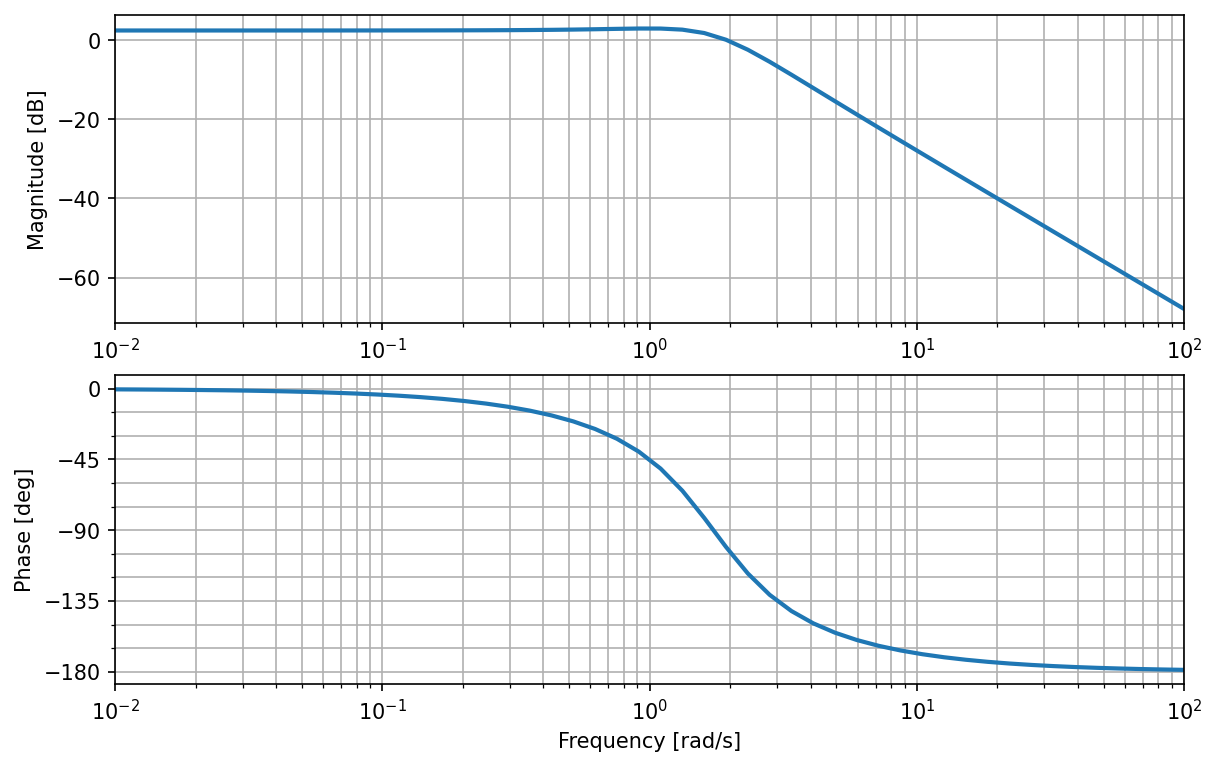

In [16]:
s = ct.tf('s')
P = 4/(s**2 + 2*s + 3)
fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ct.bode(P, np.logspace(-2,2),ax=ax)
ax[1].set_xlim(.01,100)
plt.show()

In [17]:
GM, PM, wpc, wgc = ct.margin(P)
print(f'GM = {20*np.log10(GM):2f}')
print(f'PM = {PM:2f}')
print(f'wpc = {wpc:2f}')
print(f'wgc = {wgc:2f}')


GM = inf
PM = 78.047144
wpc = nan
wgc = 1.956637


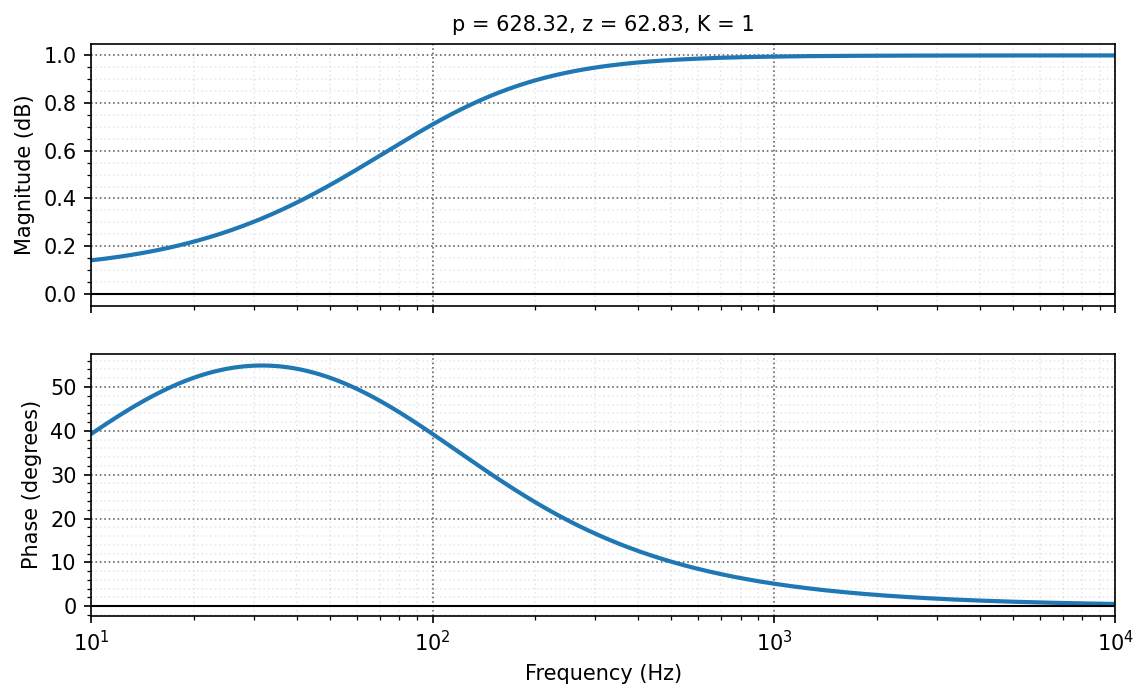

In [18]:
# Quick example of plotting for a Lead Compensator

# Define lead compensator parameters
K = 1         # Gain
z = 10*2*np.pi         # Zero at s = -10 Hz
p = 100*2*np.pi         # Pole at s = -100 Hz

# Define transfer function G(s) = K * (s + z) / (s + p)
num = [K, K * z]  # Numerator coefficients (s + z)
den = [1, p]      # Denominator coefficients (s + p)
G = ct.tf(num, den)

f = np.logspace(1, 4, 1000)
w = 2*np.pi*f
j = complex(0,1)
Gf = G(j*w)

# Generate Bode plot
fig, ax = plt.subplots(2, 1, figsize=(8, 5),sharex=True)
mag, phase = np.abs(Gf), np.angle(Gf)
ax[0].semilogx(f, mag)
ax[0].set_title('Bode Plot')
ax[0].set_ylabel('Magnitude (dB)')
ax[0].grid(which='both', axis='both')
ax[1].semilogx(f, phase * 180 / np.pi)
ax[1].set_ylabel('Phase (degrees)')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].grid(which='both', axis='both')
ax[1].set_xlim(min(f),max(f))
ax[0].set_title(f"p = {p:.2f}, z = {z:.2f}, K = {K}")
bm.nicegrid(ax)
plt.show()

## Quick Example of the impact of Free Integrators on the response of a system

1 states have been removed from the model
Type 0 System -6.000
2 states have been removed from the model
Type 1 System (-1.50 + 1.32i), (-1.50 + -1.32i)


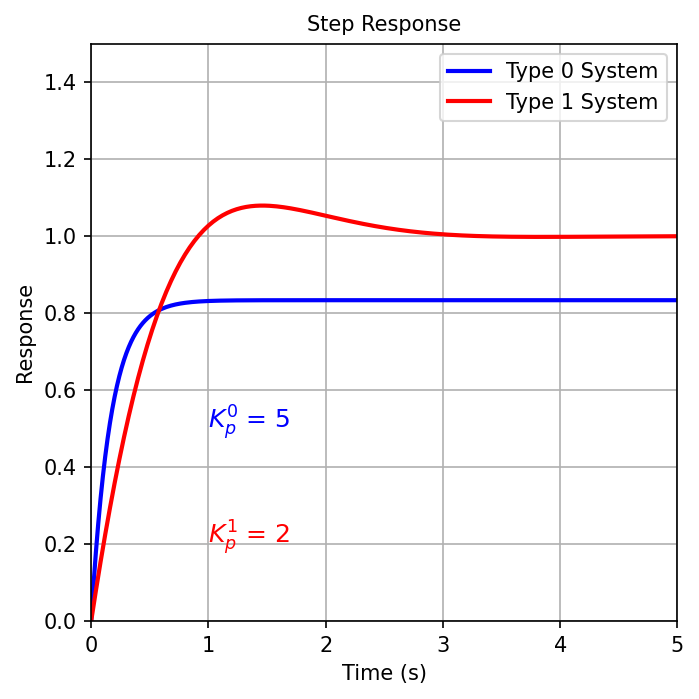

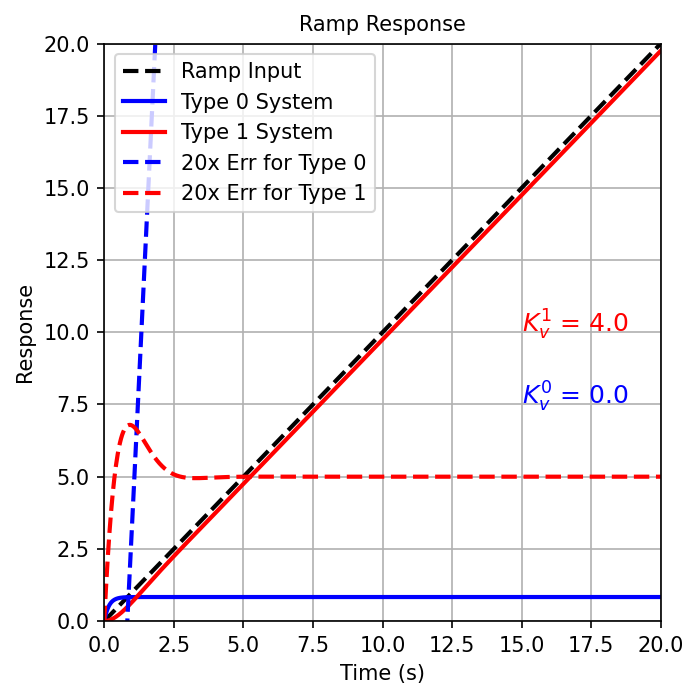

In [19]:
# Define the type 0 system (no integrator)
num0 = [1]
den0 = [1, 1]
G0 = ct.tf(num0, den0)

# Define the type 1 system (one integrator)
num1 = [1]
den1 = [1, 1, 0]
G1 = ct.tf(num1, den1)

# Stabilize the type 0 system with a proportional controller
Kp0 = 5
C0 = ct.tf([Kp0], [1])
L0 = C0 * G0
G0_cl = ct.minreal(L0/(1+L0))
cm.pretty_row_print(G0_cl.poles(), 'Type 0 System ')

# Stabilize the type 1 system with a proportional controller
Kp1 = 2
C1 = ct.tf([Kp1, 2*Kp1], [1])
L1 = C1 * G1
G1_cl = ct.minreal(L1/(1+L1))
cm.pretty_row_print(G1_cl.poles(), 'Type 1 System ')

Kv0 = cm.find_Kv(L0)
Kv1 = cm.find_Kv(L1)

# Time vector for simulation
t = np.linspace(0, 20, 1000)

# Step response
y0_step,_ = cmat.step(ct.tf2ss(G0_cl), t)
y1_step,_ = cmat.step(ct.tf2ss(G1_cl), t)

# Ramp response
y0_ramp, _ = cmat.step(ct.tf2ss(G0_cl), t)
y1_ramp,_,_ = cmat.lsim(ct.tf2ss(G1_cl), t, t)

# Plot step responses
plt.figure(figsize=(5, 5))
plt.plot(t,y0_step, 'b',label='Type 0 System')
plt.plot(t, y1_step, 'r',label='Type 1 System')
plt.title('Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.xlim([0, 5])
plt.ylim([0, 1.5])
plt.text(1, .5, f'$K_p^0$ = {Kp0}', fontsize=12, color='blue')
plt.text(1, .2, f'$K_p^1$ = {Kp1}', fontsize=12, color='red')
plt.legend()
bm.nicegrid(ax)
plt.savefig('figs/step_ramp_response_plot0.pdf',dpi=600)

# Plot ramp responses
plt.figure(figsize=(5, 5))
plt.plot(t,t,'k--',label='Ramp Input')
plt.plot(t, y0_ramp, 'b',label='Type 0 System')
plt.plot(t, y1_ramp, 'r',label='Type 1 System')
plt.plot(t, 20*(t-y0_ramp), 'b--',label='20x Err for Type 0')
plt.plot(t, 20*(t-y1_ramp), 'r--',label='20x Err for Type 1')
plt.title('Ramp Response')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.xlim([0, 20])
plt.ylim([0, 20])
plt.legend()
plt.text(15, 7.5, f'$K_v^0$ = {Kv0}', fontsize=12, color='blue')
plt.text(15, 10, f'$K_v^1$ = {Kv1}', fontsize=12, color='red')
bm.nicegrid(ax)

plt.savefig('figs/step_ramp_response_plot1.pdf',dpi=600)
plt.show()